In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/sample_data.csv')
df.head()

,Transaction Amount,Quantity,Customer Age,Is Fraudulent,Account Age Days,Transaction Hour,Payment Method_bank transfer,Payment Method_credit card,Payment Method_debit card,Device Used_mobile,Device Used_tablet,Product Category_electronics,Product Category_health & beauty,Product Category_home & garden,Product Category_toys & games
0,104.37,3,34,0,124,7,False,False,False,False,False,True,False,False,False
1,87.78,5,34,0,12,18,False,True,False,False,True,False,False,True,False
2,84.79,2,36,0,151,17,False,False,False,False,False,True,False,False,False
3,75.91,4,51,0,119,3,False,True,False,True,False,False,False,False,True
4,246.09,3,34,0,4,23,False,False,False,False,False,False,False,False,True


In [4]:
df.shape


(5000, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction Amount                5000 non-null   float64
 1   Quantity                          5000 non-null   int64  
 2   Customer Age                      5000 non-null   int64  
 3   Is Fraudulent                     5000 non-null   int64  
 4   Account Age Days                  5000 non-null   int64  
 5   Transaction Hour                  5000 non-null   int64  
 6   Payment Method_bank transfer      5000 non-null   bool   
 7   Payment Method_credit card        5000 non-null   bool   
 8   Payment Method_debit card         5000 non-null   bool   
 9   Device Used_mobile                5000 non-null   bool   
 10  Device Used_tablet                5000 non-null   bool   
 11  Product Category_electronics      5000 non-null   bool   
 12  Produc

In [6]:
df.describe()

,Transaction Amount,Quantity,Customer Age,Is Fraudulent,Account Age Days,Transaction Hour
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,228.595394,2.960400,34.453800,0.045800,180.066600,11.213400
std,282.186027,1.418744,10.067221,0.209072,107.649449,6.999061
min,10.140000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,72.077500,2.000000,28.000000,0.000000,85.000000,5.000000
50%,153.870000,3.000000,35.000000,0.000000,180.000000,11.000000
75%,296.687500,4.000000,41.000000,0.000000,274.250000,17.000000
max,6351.300000,5.000000,72.000000,1.000000,365.000000,23.000000


In [7]:
df.isnull().sum()

,0
Transaction Amount,0
Quantity,0
Customer Age,0
Is Fraudulent,0
Account Age Days,0
Transaction Hour,0
Payment Method_bank transfer,0
Payment Method_credit card,0
Payment Method_debit card,0
Device Used_mobile,0


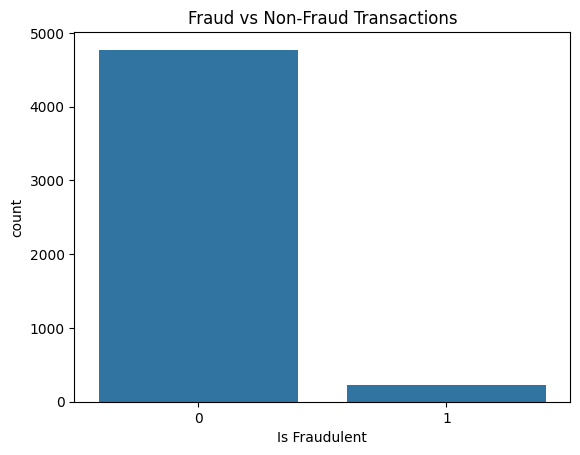

In [8]:
sns.countplot(x='Is Fraudulent', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

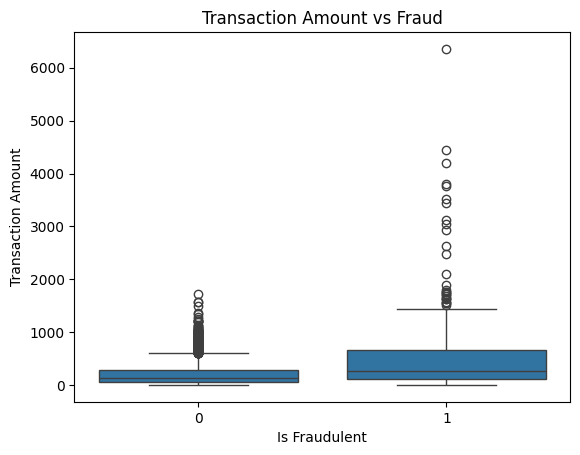

In [9]:
sns.boxplot(x='Is Fraudulent', y='Transaction Amount', data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

<Axes: xlabel='Transaction Amount'>

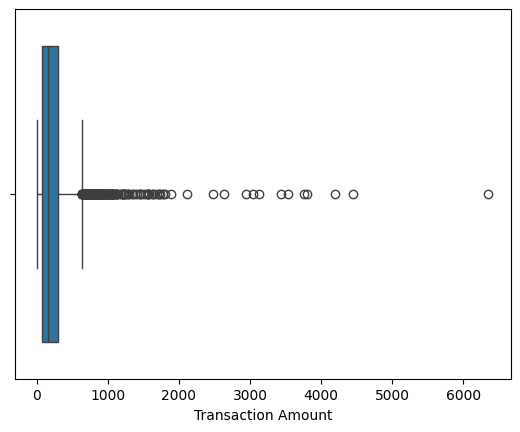

In [10]:
sns.boxplot(x=df['Transaction Amount'])

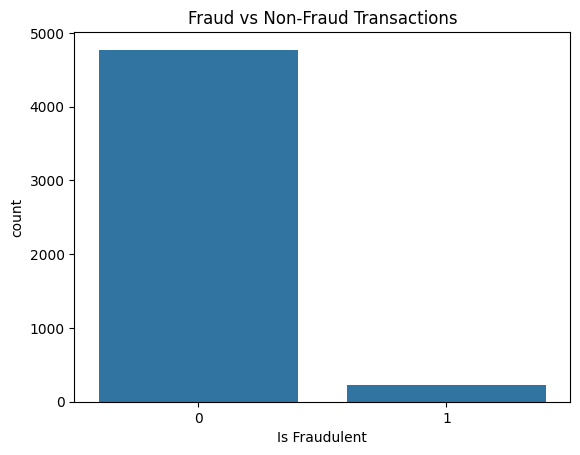

In [12]:
sns.countplot(x='Is Fraudulent', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

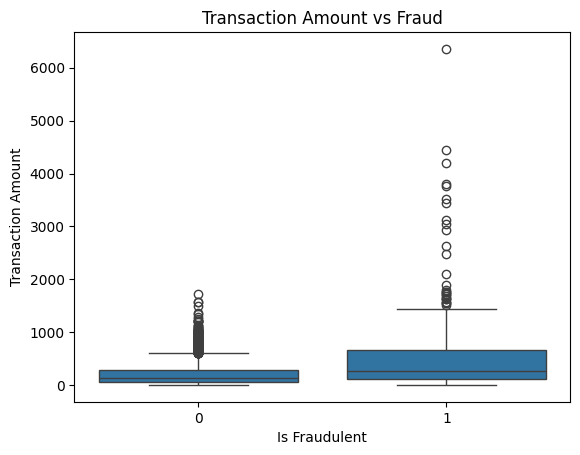

In [13]:
sns.boxplot(x='Is Fraudulent', y='Transaction Amount', data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

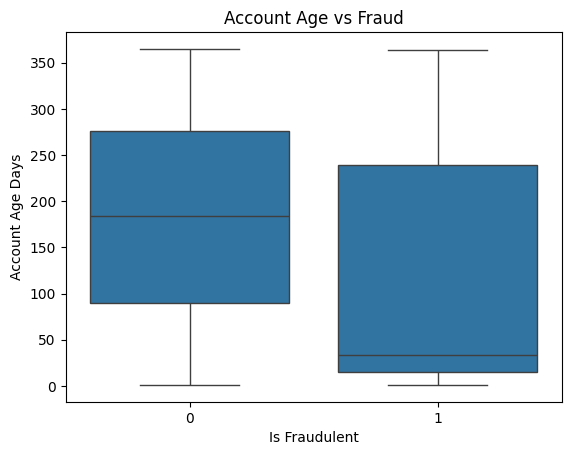

In [15]:
sns.boxplot(x='Is Fraudulent', y='Account Age Days', data=df)
plt.title("Account Age vs Fraud")
plt.show()

In [18]:
def get_payment_method(row):
    if row['Payment Method_bank transfer']:
        return 'bank transfer'
    elif row['Payment Method_credit card']:
        return 'credit card'
    elif row['Payment Method_debit card']:
        return 'debit card'
    return 'unknown' # Fallback in case none are true

df['Payment Method'] = df.apply(get_payment_method, axis=1)

display(df[['Payment Method_bank transfer', 'Payment Method_credit card', 'Payment Method_debit card', 'Payment Method']].head())

,Payment Method_bank transfer,Payment Method_credit card,Payment Method_debit card,Payment Method
0,False,False,False,unknown
1,False,True,False,credit card
2,False,False,False,unknown
3,False,True,False,credit card
4,False,False,False,unknown


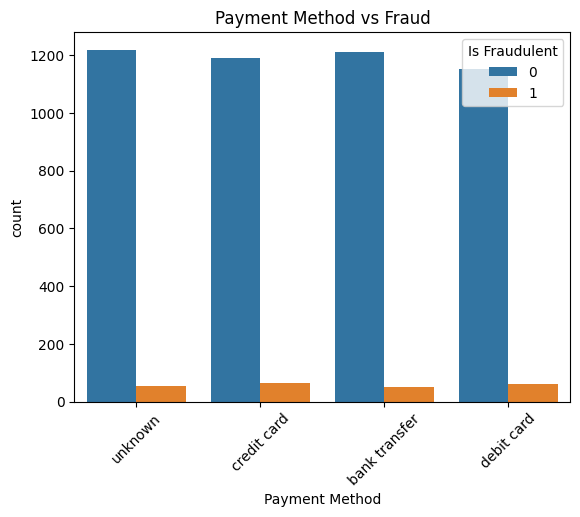

In [19]:
sns.countplot(x='Payment Method', hue='Is Fraudulent', data=df)
plt.title("Payment Method vs Fraud")
plt.xticks(rotation=45)
plt.show()

In [22]:
def get_device_used(row):
    if row['Device Used_mobile']:
        return 'mobile'
    elif row['Device Used_tablet']:
        return 'tablet'
    return 'desktop' # Assuming if not mobile or tablet, it's desktop

df['Device Used'] = df.apply(get_device_used, axis=1)

display(df[['Device Used_mobile', 'Device Used_tablet', 'Device Used']].head())

,Device Used_mobile,Device Used_tablet,Device Used
0,False,False,desktop
1,False,True,tablet
2,False,False,desktop
3,True,False,mobile
4,False,False,desktop


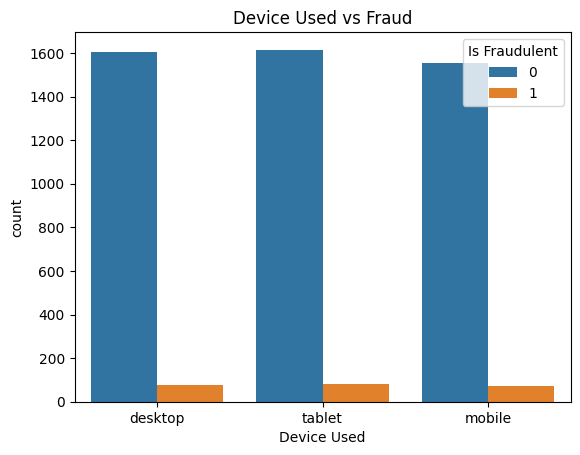

In [23]:
sns.countplot(x='Device Used', hue='Is Fraudulent', data=df)
plt.title("Device Used vs Fraud")
plt.show()

In [24]:
df = pd.get_dummies(df, drop_first=True)

In [25]:
X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.956

Confusion Matrix:
 [[948   4]
 [ 40   8]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       952
           1       0.67      0.17      0.27        48

    accuracy                           0.96      1000
   macro avg       0.81      0.58      0.62      1000
weighted avg       0.95      0.96      0.94      1000



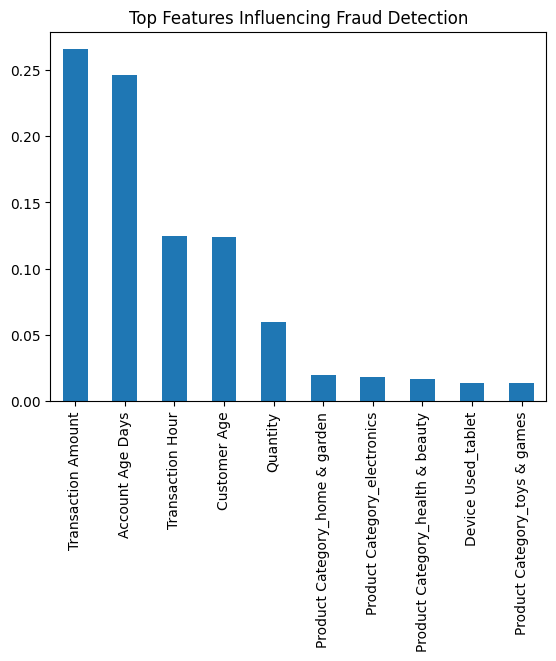

In [30]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Features Influencing Fraud Detection")
plt.show()